In [1]:
# Core
import os
import time
import requests
import pandas as pd
import numpy as np

# Market data
import yfinance as yf

# NLP
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Statistics
import statsmodels.api as sm


/Users/meetkumarpatel/Personal Projects/my-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# YahooFinance

def fetch_ohlcv(symbol: str, period: str = "1y") -> pd.DataFrame:
    data = yf.Ticker(symbol)
    history = data.history(period=period)
    
    history.drop(['Dividends', 'Stock Splits'], axis=1, inplace=True)
    history.index = history.index.tz_localize(None)
    
    return history


In [3]:
def fetch_news(symbols, start, end, api_key, api_secret):
    url = "https://data.alpaca.markets/v1beta1/news?"
    headers = {
        "accept": "application/json",
        "APCA-API-KEY-ID": api_key,
        "APCA-API-SECRET-KEY": api_secret
    }
    
    all_articles = []
    page_token = None

    while True:
        params = {
            "start": start,
            "end": end,
            "symbols": ",".join(symbols),
            "limit": 50,
            "include_content": True,
            "exclude_contentless": True,
            "sort": "asc",
            "page_token": page_token
        }

        r = requests.get(url, headers=headers, params=params)
        r.raise_for_status()
        data = r.json()

        all_articles.extend(data["news"])
        page_token = data.get("next_page_token")

        if page_token is None:
            break

        time.sleep(0.2)  # API safety

    return pd.DataFrame(all_articles)


In [4]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("\n", " ")
    return text


In [5]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"


In [6]:

#tokenizer integration for pre training data
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
# model integration to infer it with pre trained data
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(device)
# model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

labels = {0: "negative", 1: "neutral", 2: "positive"}


In [7]:
def score_sentiment(texts):
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**inputs)

    scores = torch.softmax(outputs.logits, dim=1).numpy()
    sentiment = scores[:, 2] - scores[:, 0]  # positive − negative

    return sentiment


In [8]:
def aggregate_daily_sentiment(news_df):
    news_df["created_at"] = pd.to_datetime(news_df["created_at"]).dt.date
    news_df["content"] = news_df["content"].apply(clean_text)

    news_df["sentiment"] = score_sentiment(news_df["content"].tolist())

    daily_sentiment = (
        news_df
        .groupby("created_at")["sentiment"]
        .mean()
        .to_frame("daily_sentiment")
    )

    return daily_sentiment


In [9]:
def compute_returns(price_df):
    returns = price_df["Close"].pct_change().dropna()
    returns.name = "returns"
    return returns


In [10]:
def build_research_table(price_df, sentiment_df):
    df = price_df.copy()
    df["date"] = df.index.date

    merged = df.merge(
        sentiment_df,
        left_on="date",
        right_index=True,
        how="inner"
    )

    merged["returns"] = merged["Close"].pct_change()
    merged.dropna(inplace=True)

    return merged


In [11]:
def run_regression(df):
    X = sm.add_constant(df["daily_sentiment"])
    y = df["returns"]

    model = sm.OLS(y, X).fit()
    return model


In [12]:
symbols = ["MSFT"]

price = fetch_ohlcv("MSFT", "1y")

news = fetch_news(
    symbols=symbols,
    start="2025-01-03T00:00:00Z",
    end="2025-10-03T00:00:00Z",
    api_key="PKDOOOL44COZGZB6E7KNQAFMOF",
    api_secret="FZSHhs41VmSSU8z7otcQfHMJEFFuqHzSuMLZVuixrexZ"
)

daily_sentiment = aggregate_daily_sentiment(news)

dataset = build_research_table(price, daily_sentiment)

results = run_regression(dataset)

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.7181
Date:                Thu, 01 Jan 2026   Prob (F-statistic):              0.398
Time:                        12:01:55   Log-Likelihood:                 502.90
No. Observations:                 186   AIC:                            -1002.
Df Residuals:                     184   BIC:                            -995.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0017      0.001     

## Interpretation of regression results

**High-level takeaway:** With the current setup, daily FinBERT news sentiment for MSFT does **not** show a statistically significant linear relationship with next-day returns.

Key points from the OLS summary:

- **R-squared ≈ 0.005**: Daily sentiment explains **~0.5%** of the variation in returns, which is extremely low.
- **Coefficient on `daily_sentiment` ≈ -0.0058**: The sign is slightly negative, but the magnitude is very small.
- **p-value for `daily_sentiment` ≈ 0.318**: This is much larger than common significance thresholds (0.05 or 0.10), so we **fail to reject** the null hypothesis that the coefficient is zero.
- **Intercept ≈ 0.0016** with p-value ≈ 0.225: Also not significantly different from zero.
- **Diagnostic tests (Omnibus, Jarque-Bera, high kurtosis)**: Indicate that residuals are **non-normal** with heavy tails and skewness, which is common in financial returns.

**Interpretation in words:**

- For this sample (MSFT, ~1 year, Alpaca news, FinBERT sentiment), there is **no strong evidence** that days with higher news sentiment correspond to meaningfully different returns the next day.
- The market may already efficiently price in the information in news sentiment, or you may need a richer feature set (lags, interactions, non-linear models, intraday data, etc.).
- These results do **not** mean sentiment is useless, only that in this simple linear daily regression setup, it doesn’t show a clear predictive edge.

Below, we add plots to visually inspect the relationship and residuals.


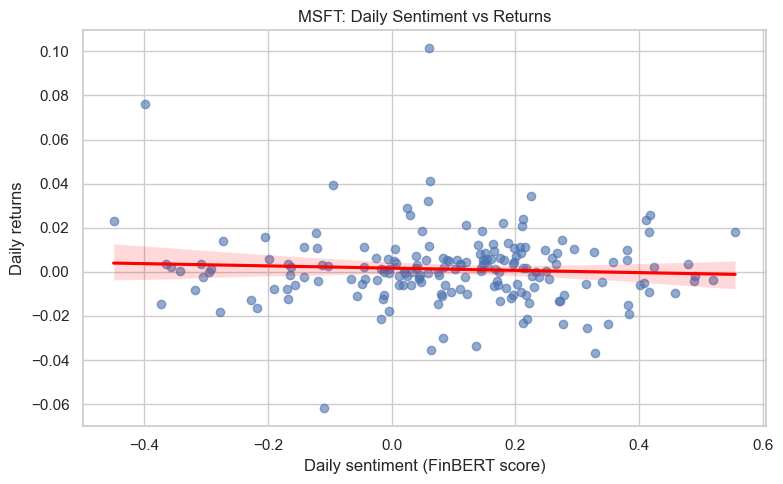

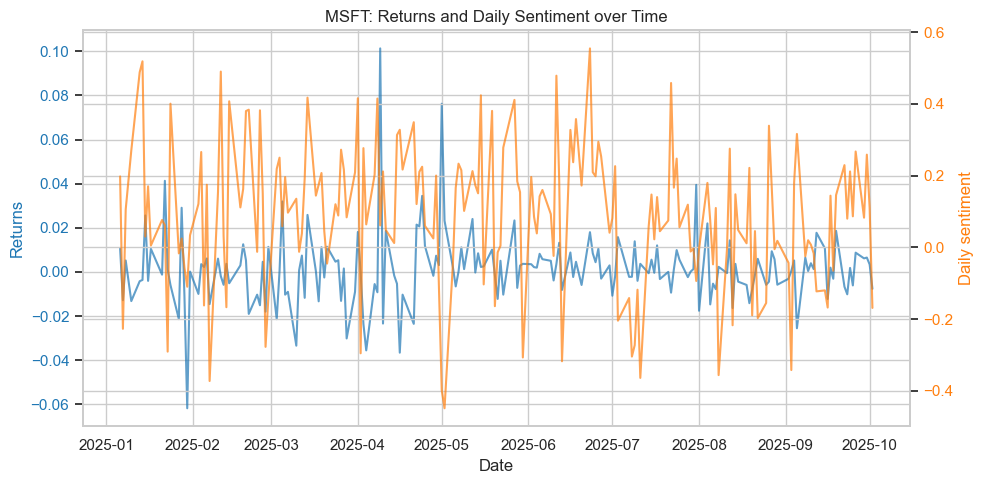

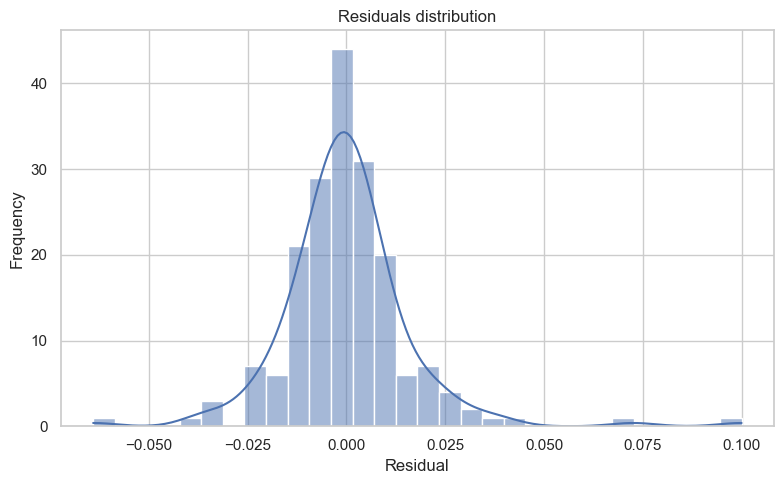

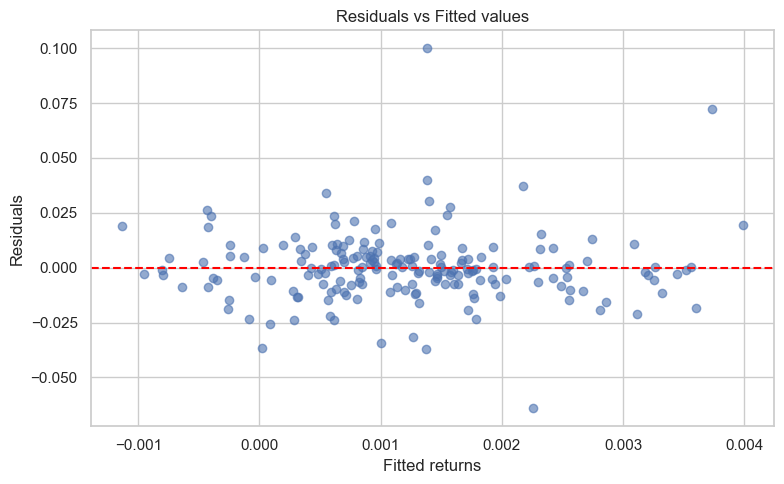

In [13]:
# Visual diagnostics for the regression

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1) Scatter plot of daily_sentiment vs returns with regression line
plt.figure(figsize=(8, 5))
sns.regplot(x="daily_sentiment", y="returns", data=dataset, line_kws={"color": "red"}, scatter_kws={"alpha": 0.6})
plt.title("MSFT: Daily Sentiment vs Returns")
plt.xlabel("Daily sentiment (FinBERT score)")
plt.ylabel("Daily returns")
plt.tight_layout()
plt.show()

# 2) Time series of sentiment and returns
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(dataset.index, dataset["returns"], color="tab:blue", alpha=0.7, label="Returns")
ax1.set_xlabel("Date")
ax1.set_ylabel("Returns", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(dataset.index, dataset["daily_sentiment"], color="tab:orange", alpha=0.7, label="Daily sentiment")
ax2.set_ylabel("Daily sentiment", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("MSFT: Returns and Daily Sentiment over Time")
fig.tight_layout()
plt.show()

# 3) Residuals histogram + KDE
residuals = results.resid

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 4) Residuals vs fitted values
fitted = results.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Fitted values")
plt.xlabel("Fitted returns")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()


In [ ]:
# Utility to save model, dataset, and results locally

from datetime import datetime

# Configure a base directory (relative to this notebook) where artifacts will be stored
BASE_SAVE_DIR = "artifacts"


def save_experiment(run_name: str,
                    model, tokenizer,
                    dataset: pd.DataFrame,
                    regression_results,
                    extra_metadata: dict | None = None):
    """Save model, tokenizer, dataset, regression results, and summary to disk.

    Parameters
    ----------
    run_name : str
        Name for this experiment run (used to create a subfolder).
    model : transformers.PreTrainedModel
        Trained (or fine-tuned) model to save.
    tokenizer : transformers.PreTrainedTokenizer
        Tokenizer associated with the model.
    dataset : pd.DataFrame
        Final dataset used in the research / regression.
    regression_results : statsmodels.regression.linear_model.RegressionResultsWrapper
        Fitted regression results object from `run_regression`.
    extra_metadata : dict | None
        Any additional information you want to persist (hyperparams, notes, etc.).
    """
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_folder = f"{run_name}_{timestamp}"
    save_path = os.path.join(BASE_SAVE_DIR, run_folder)
    os.makedirs(save_path, exist_ok=True)

    # 1) Save HF model + tokenizer (creates a folder with config + weights)
    model_dir = os.path.join(save_path, "hf_model")
    os.makedirs(model_dir, exist_ok=True)
    model.save_pretrained(model_dir)
    tokenizer.save_pretrained(model_dir)

    # 2) Save dataset
    dataset_path = os.path.join(save_path, "dataset.csv")
    dataset.to_csv(dataset_path, index=True)

    # 3) Save regression results summary
    summary_txt_path = os.path.join(save_path, "regression_summary.txt")
    with open(summary_txt_path, "w") as f:
        f.write(regression_results.summary().as_text())

    # 4) Save regression parameters / metadata as JSON
    summary_json_path = os.path.join(save_path, "regression_metadata.json")
    metadata = {
        "params": regression_results.params.to_dict(),
        "pvalues": regression_results.pvalues.to_dict(),
        "rsquared": float(regression_results.rsquared),
        "rsquared_adj": float(regression_results.rsquared_adj),
        "run_name": run_name,
        "created_at": timestamp,
    }
    if extra_metadata:
        metadata.update(extra_metadata)

    import json

    with open(summary_json_path, "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Artifacts saved to: {save_path}")



In [ ]:
# Save current in-memory experiment (model, tokenizer, dataset, regression results)

save_experiment(
    run_name="msft_daily_sentiment_ols",
    model=model,                 # HF sentiment model already in memory
    tokenizer=tokenizer,         # HF tokenizer already in memory
    dataset=dataset,             # research table from build_research_table
    regression_results=results,  # OLS results from run_regression
    extra_metadata={
        "symbols": symbols,
        "yahoo_period": "1y",
        "news_start": "2025-01-03T00:00:00Z",
        "news_end": "2025-10-03T00:00:00Z",
    },
)


Artifacts saved to: artifacts/msft_daily_sentiment_ols_20260101-120156


In [ ]:
# Example usage (after training / running regression above):
# save_experiment(
#     run_name="msft_daily_sentiment_ols",
#     model=model,                 # HF sentiment model
#     tokenizer=tokenizer,         # HF tokenizer
#     dataset=dataset,             # research table
#     regression_results=results,  # OLS results from run_regression
#     extra_metadata={
#         "symbols": symbols,
#         "yahoo_period": "1y",
#         "news_start": "2024-01-03T00:00:00Z",
#         "news_end": "2025-10-03T00:00:00Z",
#     },
# )